In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import seaborn as sns_plt
from imblearn.over_sampling import SMOTE
from lifelines import KaplanMeierFitter, CoxPHFitter

# Setup the Output Directory
output_dir = "/content/Output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

In [ ]:
#####################
# EXTRACT .RAR DATA
######################

# File path
rar_file_path = "/content/Datasets- Diabetes and Hypertension Data.rar"

# Extract the file
!unrar e "{rar_file_path}"

print("\n--- NEWLY EXTRACTED CSV FILES ---")
csv_files = [f for f in os.listdir('/content/') if f.endswith('.csv')]
for file in csv_files:
    print(f"- {file}")


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/Datasets- Diabetes and Hypertension Data.rar

Extracting  Additional Columns.csv                                         0%  OK 
Extracting  HTN_Additional Columns.csv                                     0%  OK 
Extracting  Dialysis.csv                                                   0%  OK 
Extracting  Neurology.csv                                                  0%  OK 
Extracting  Opthamol.csv                                                   0%  OK 
Extracting  Physician.csv                                                  0%  OK 
Extracting  Diabetes Adherence Data.csv                                    6%  OK 
Extracting  HTN Adherence Data.csv                                        25% 31%  OK 
Extracting  Final Prepared Dataset - Diabetes and Hypertension Data.xlsx      36%  OK 
Extracting  N

In [ ]:

# Files we want to inspect
files_to_check = [
    "Diabetes Adherence Data.csv",
    "HTN Adherence Data.csv",
    "Dialysis.csv",
    "Opthamol.csv",
    "Additional Columns.csv",
    "Physician.csv",
    "HTN_Additional Columns.csv",
    "Neurology.csv"
]

# Quickly explore the files
for file in files_to_check:
    print(f"\n{'='*50}")
    print(f"🩺 INSPECTING: {file}")
    print(f"{'='*50}")

    file_path = f"/content/{file}"
    df = pd.read_csv(file_path)

    # Print the vital signs
    print(f"Total Patients (Rows): {df.shape[0]}")
    print(f"Total Features (Columns): {df.shape[1]}\n")

    print("--- COLUMN NAMES ---")
    print(df.columns.tolist())

    print("\n--- DATA PREVIEW (First 3 Rows) ---")
    display(df.head(3))


🩺 INSPECTING: Diabetes Adherence Data.csv
Total Patients (Rows): 52616
Total Features (Columns): 41

--- COLUMN NAMES ---
['MEMBER', 'INO', 'PZTIQNT NZXQ', 'ADHERENCE', 'GENDER', 'PRACTICE NO', 'DIS', 'PROVIDER', 'AS AT NETWORKS', 'REFERRING PRACTICE', 'PAYER NAME', 'INV REF', 'SERVICE DATE', 'ASSESS DATE', 'DATE RECEIVED', 'CLM CODE', 'CODE DESCRIPTION', 'UNITS', 'SCRIPT CODE', 'AMOUNT CLAIMED', 'PAID FROM RISK AMT', 'PAID FROM THRESHHOLD', 'PAID FROM SAVINGS', 'RECOVERY AMOUNT', 'TOTAL AMOUNT PAID', 'TARIFF', 'CO-PAY', 'PAY TO', 'REJ', 'REV', 'AUTH NO', 'DL', 'CLAIM NO', 'CLAIM LINE NO', 'DUPLICATE CLAIM', 'DUPLICATE CLAIM LINE', 'OPTION NAME', 'PAPER/EDI', 'ASSESSOR NAME', 'BIRTHDATE', 'CURRENT AGE']

--- DATA PREVIEW (First 3 Rows) ---


,MEMBER,INO,PZTIQNT NZXQ,ADHERENCE,GENDER,PRACTICE NO,DIS,PROVIDER,AS AT NETWORKS,REFERRING PRACTICE,...,DL,CLAIM NO,CLAIM LINE NO,DUPLICATE CLAIM,DUPLICATE CLAIM LINE,OPTION NAME,PAPER/EDI,ASSESSOR NAME,BIRTHDATE,CURRENT AGE
0,98788489,0,XS TZFZDZWZ NYZPIXBI,2,F,860662,60,81302 PLUS TWO PHARMACY,NaN,847321.0,...,N,3285628,7248261,NaN,NaN,STUDYMATE PRIVATE,EDI,CIMAS_HEALTH263 ADMIN,11/7/1999,24
1,98795328,0,XR TSITSIKZYI XUDOTI,7,M,877344,60,92398 CIMAS HCC MUTARE PHARMACY,CIMAS PHARMACIES (2123),866776.0,...,N,2760001,6299632,NaN,NaN,ICARE,EDI,CIMAS_HEALTH263 ADMIN,3/7/1970,53
2,98795328,0,XR TSITSIKZYI XUDOTI,7,M,877344,60,92398 CIMAS HCC MUTARE PHARMACY,CIMAS PHARMACIES (2123),866776.0,...,N,2760001,6299633,NaN,NaN,ICARE,EDI,CIMAS_HEALTH263 ADMIN,3/7/1970,53



🩺 INSPECTING: HTN Adherence Data.csv


/tmp/ipykernel_1990/3767535407.py:21: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Total Patients (Rows): 218816
Total Features (Columns): 41

--- COLUMN NAMES ---
['MEMBER', 'INO', 'PZTIQNT NZXQ', 'ADHERENCE', 'GENDER', 'PRACTICE NO', 'DIS', 'PROVIDER', 'AS AT NETWORKS', 'REFERRING PRACTICE', 'PAYER NAME', 'INV REF', 'SERVICE DATE', 'ASSESS DATE', 'DATE RECEIVED', 'CLM CODE', 'CODE DESCRIPTION', 'UNITS', 'SCRIPT CODE', 'AMOUNT CLAIMED', 'PAID FROM RISK AMT', 'PAID FROM THRESHHOLD', 'PAID FROM SAVINGS', 'RECOVERY AMOUNT', 'TOTAL AMOUNT PAID', 'TARIFF', 'CO-PAY', 'PAY TO', 'REJ', 'REV', 'AUTH NO', 'DL', 'CLAIM NO', 'CLAIM LINE NO', 'DUPLICATE CLAIM', 'DUPLICATE CLAIM LINE', 'OPTION NAME', 'PAPER/EDI', 'ASSESSOR NAME', 'BIRTHDATE', 'CURRENT AGE']

--- DATA PREVIEW (First 3 Rows) ---


...

,BENEFICIARY,PHYSICIAN
0,977856430,Physician
1,977879360,Physician
2,977897830,Physician



🩺 INSPECTING: HTN_Additional Columns.csv
Total Patients (Rows): 10
Total Features (Columns): 4

--- COLUMN NAMES ---
['OPTION NAME', 'SCHEMETYPE', 'COVERTYPE', 'ANNUALCONTRIBUTION']

--- DATA PREVIEW (First 3 Rows) ---


,OPTION NAME,SCHEMETYPE,COVERTYPE,ANNUALCONTRIBUTION
0,STUDYMATE PUBLIC,BASIC,STANDARD,211764.0
1,STUDYMATE PRIVATE,BASIC,STANDARD,690384.0
2,BASICARE,BASIC,STANDARD,808284.0



🩺 INSPECTING: Neurology.csv
Total Patients (Rows): 98
Total Features (Columns): 2

--- COLUMN NAMES ---
['BENEFICIARY', 'NEUROLOGY']

--- DATA PREVIEW (First 3 Rows) ---


,BENEFICIARY,NEUROLOGY
0,979297520,Neurology
1,979297520,Neurology
2,979876490,Neurology


In [ ]:
#############
# Data Merge
#############

print("1/5: Loading Raw Data...")
# Clinical claims datasets
df_htn = pd.read_csv("/content/HTN Adherence Data.csv", low_memory=False)
df_dia = pd.read_csv("/content/Diabetes Adherence Data.csv", low_memory=False)
# Economic plan catalog
df_plans = pd.read_csv("/content/Additional Columns.csv")

print("2/5: Combining Disease Cohorts...")
# Tagging groups before stacking
df_htn['DISEASE_GROUP'] = 'Hypertension'
df_dia['DISEASE_GROUP'] = 'Diabetes'
df_combined = pd.concat([df_htn, df_dia], ignore_index=True)

print("3/5: Merging Insurance Plan Economics...")
# Bridge the patient claims to the plan details using 'OPTION NAME'
df_master = df_combined.merge(df_plans, on='OPTION NAME', how='left')

print("4/5: Aggregating Claims to Patient Level...")
# Fix the adherence overlap (max 12 months)
df_master['ADHERENCE'] = df_master['ADHERENCE'].clip(upper=12)

# Define the roll-up logic (compressing multiple claims into one patient row)
agg_rules = {
    'ADHERENCE': 'max',             # Used to calculate target
    'CURRENT AGE': 'first',
    'GENDER': 'first',
    'DISEASE_GROUP': 'first',
    'SCHEMETYPE': 'first',
    'COVERTYPE': 'first',
    'ANNUALCONTRIBUTION': 'first',
    'TOTAL AMOUNT PAID': 'sum',     # Total spend (leaky)
    'CO-PAY': 'sum',                # Out-of-pocket (mostly zeros)
    'CLAIM NO': 'count'             # Total pharmacy visits
}

df_patients = df_master.groupby('MEMBER').agg(agg_rules).reset_index()
df_patients = df_patients.rename(columns={'CLAIM NO': 'TOTAL_PHARMACY_VISITS'})

print("5/5: Final Cleaning & Feature Selection...")
# Create our binary Target (1 = Non-Adherent, 0 = Adherent)
df_patients['TARGET_NON_ADHERENT'] = (df_patients['ADHERENCE'] < 10).astype(int)

# DROP columns that cause 'Data Leakage' or contain zero information
cols_to_drop = ['ADHERENCE', 'CO-PAY', 'TOTAL AMOUNT PAID']
df_final = df_patients.drop(columns=cols_to_drop)

# Remove the single row with missing insurance data found in EDA
df_final = df_final.dropna().reset_index(drop=True)

print("\n" + "="*45)
print("✅ DATA MERGE COMPLETE")
print("="*45)
print(f"Total Unique Patients: {df_final.shape[0]}")
print(f"Total Columns:         {df_final.shape[1]}")

display(df_final.head())

Step 1: Loading Raw Data...
Step 2: Combining Disease Cohorts...
Step 3: Merging Insurance Plan Economics...
Step 4: Aggregating Claims to Patient Level...
Step 5: Final Cleaning & Feature Selection...

✅ DATA MERGE COMPLETE
Total Unique Patients: 16834
Total Columns:         9


,MEMBER,CURRENT AGE,GENDER,DISEASE_GROUP,SCHEMETYPE,COVERTYPE,ANNUALCONTRIBUTION,TOTAL_PHARMACY_VISITS,TARGET_NON_ADHERENT
0,92222365,48,F,Hypertension,PREMIUM,COMPREHENSIVE,6740121.0,1,1
1,92222436,75,M,Hypertension,PREMIUM,COMPREHENSIVE,6740121.0,18,1
2,92222445,60,M,Hypertension,PREMIUM,COMPREHENSIVE,6740121.0,3,1
3,92222489,42,M,Hypertension,PREMIUM,COMPREHENSIVE,6740121.0,12,0
4,92222828,39,M,Hypertension,PREMIUM,STANDARD,6889900.0,14,1


=== STARTING DESCRIPTIVE ANALYSIS ===



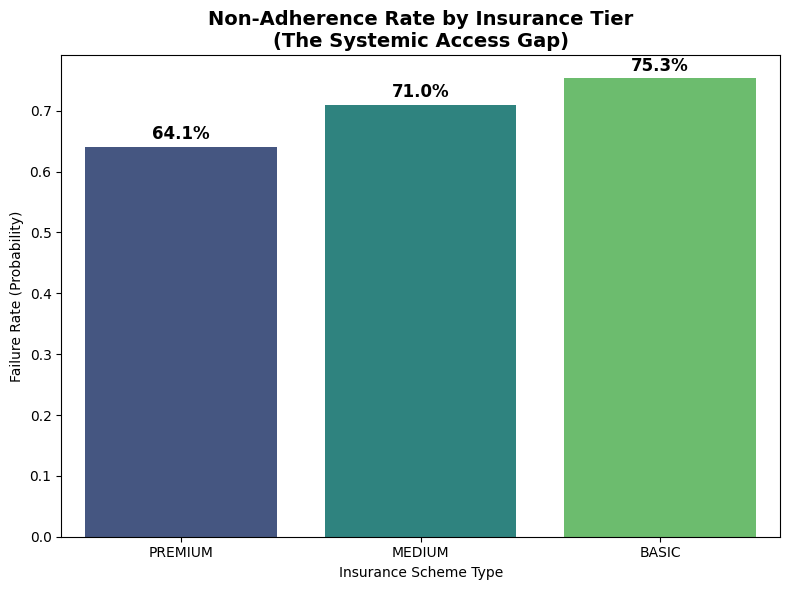

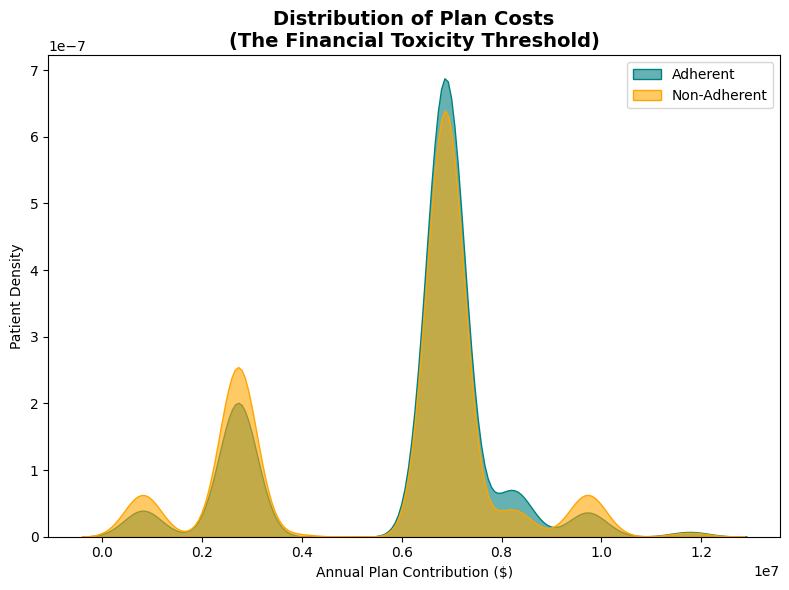

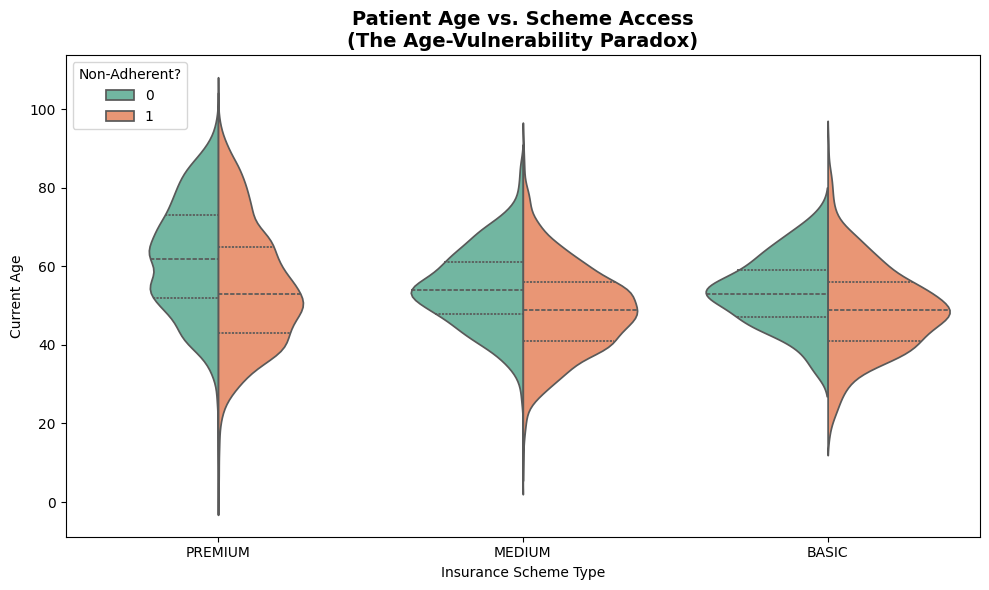


✅ Success! 3 High-Res PNGs saved to /content/Output/


In [ ]:
#######################
# Descriptive Analysis
#######################

print("=== STARTING DESCRIPTIVE ANALYSIS ===")

df_plot = df_final.copy()

# VISUAL 1: THE SYSTEMIC GAP (Bar Chart)
plt.figure(figsize=(8, 6))
ax1 = sns.barplot(x='SCHEMETYPE', y='TARGET_NON_ADHERENT', data=df_plot,
                  palette='viridis', errorbar=None, hue='SCHEMETYPE', legend=False)
plt.title('Non-Adherence Rate by Insurance Tier\n(The Systemic Access Gap)', fontsize=14, fontweight='bold')
plt.ylabel('Failure Rate (Probability)')
plt.xlabel('Insurance Scheme Type')

# Add percentage labels
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/Output/1_Systemic_Gap_Analysis.png', dpi=300)
plt.show()

# VISUAL 2: PLAN COST DENSITY (KDE Plot)
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df_plot[df_plot['TARGET_NON_ADHERENT']==0], x='ANNUALCONTRIBUTION',
            label='Adherent', fill=True, color='teal', alpha=0.6)
sns.kdeplot(data=df_plot[df_plot['TARGET_NON_ADHERENT']==1], x='ANNUALCONTRIBUTION',
            label='Non-Adherent', fill=True, color='orange', alpha=0.6)
plt.title('Distribution of Plan Costs\n(The Financial Toxicity Threshold)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Plan Contribution ($)')
plt.ylabel('Patient Density')
plt.legend()
plt.tight_layout()
plt.savefig('/content/Output/2_Plan_Cost_Density.png', dpi=300)
plt.show()

# VISUAL 3: AGE X SCHEME INTERACTION (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(x='SCHEMETYPE', y='CURRENT AGE', hue='TARGET_NON_ADHERENT',
               data=df_plot, split=True, inner="quart", palette='Set2')
plt.title('Patient Age vs. Scheme Access\n(The Age-Vulnerability Paradox)', fontsize=14, fontweight='bold')
plt.xlabel('Insurance Scheme Type')
plt.ylabel('Current Age')
plt.legend(title='Non-Adherent?', loc='upper left')
plt.tight_layout()
plt.savefig('/content/Output/3_Age_Scheme_Demographics.png', dpi=300)
plt.show()

print("\n✅ Success! 3 High-Res PNGs saved to /content/Output/")

In [ ]:
###############
# ML DATA PREP
###############

print("=== STARTING ML DATA PREP ===\n")

# Define Features (X) and Target (y)
y = df_final['TARGET_NON_ADHERENT']
X = df_final.drop(columns=['TARGET_NON_ADHERENT', 'MEMBER'])

# One-Hot Encode categorical variables (Gender, Disease, Scheme, Cover)
X_encoded = pd.get_dummies(X, drop_first=True)

# Split the data (80% Training, 20% Testing)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Feature names for the charts
feature_names = X_encoded.columns
print(f"Training on {X_train.shape[0]} patients, Testing on {X_test.shape[0]} patients.\n")

print("=== ML DATA PREP DONE ===\n")

=== STARTING ML DATA PREP ===

Training on 13467 patients, Testing on 3367 patients.

=== ML DATA PREP DONE ===



TRAINING LASSO (L1) REGRESSION...
🏆 Lasso (L1) ROC-AUC Score: 0.8815

=== 1. CROSS-VALIDATION (ROBUSTNESS CHECK) ===
CV ROC-AUC Scores across 5 folds: [0.8842 0.8827 0.8941 0.8833 0.8851]
🌟 Average CV ROC-AUC: 0.8859 (± 0.0084)

=== 2. CLINICAL METRICS (OPERATIONS CHECK) ===
Classification Report:
                  precision    recall  f1-score   support

    Adherent (0)       0.67      0.72      0.69      1138
Non-Adherent (1)       0.85      0.82      0.83      2229

        accuracy                           0.79      3367
       macro avg       0.76      0.77      0.76      3367
    weighted avg       0.79      0.79      0.79      3367



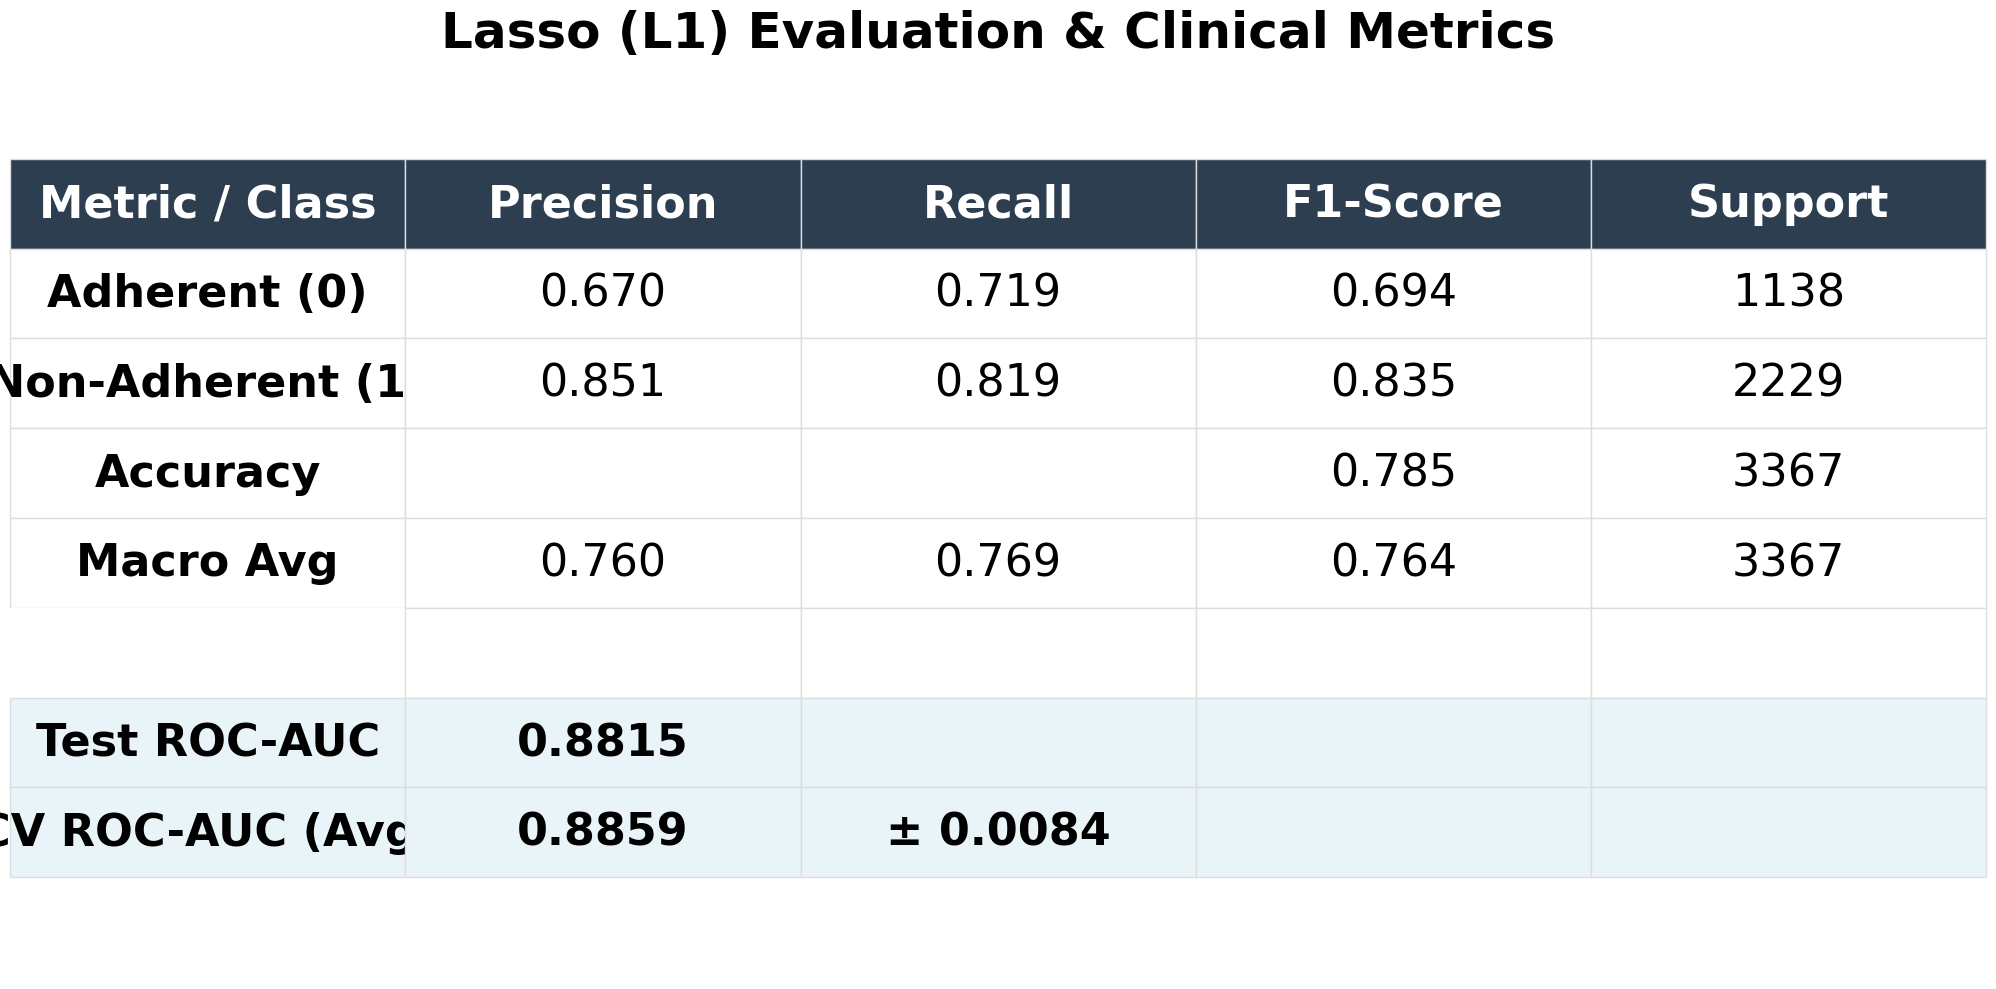


=== 4. EXTRACTING SYSTEMIC RISK FACTORS (LASSO) ===
Positive (+) = Increases risk of Non-Adherence
Negative (-) = Protects against Non-Adherence
--------------------------------------------------
                   Feature  Coefficient
        ANNUALCONTRIBUTION     0.102396
                  GENDER_M     0.092494
DISEASE_GROUP_Hypertension     0.048465
        COVERTYPE_STANDARD    -0.029822
               CURRENT AGE    -0.111041
        SCHEMETYPE_PREMIUM    -0.113899
     TOTAL_PHARMACY_VISITS    -2.080354


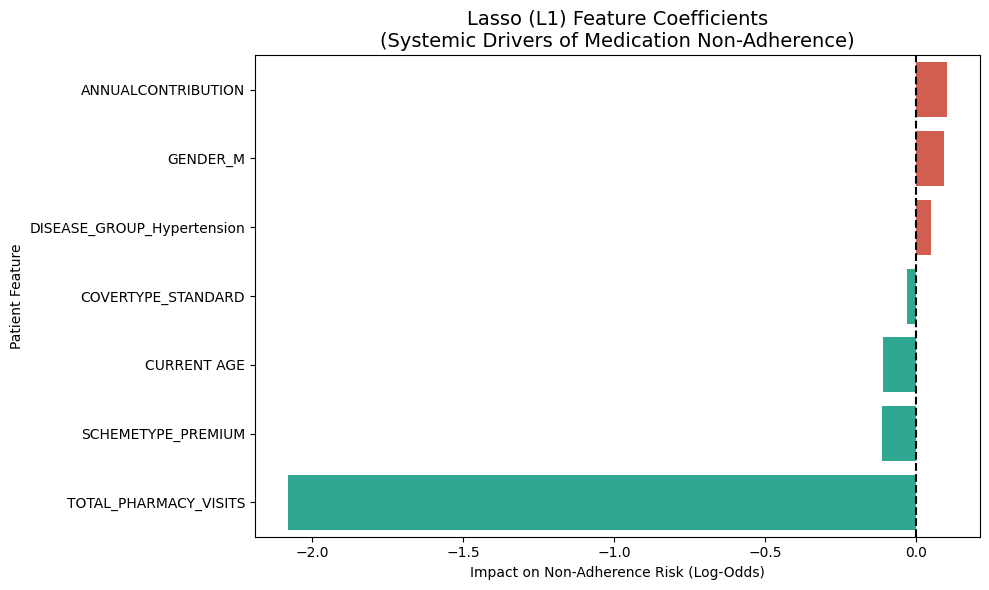


Success! ML Pipeline complete.


In [ ]:
#######################################
# LOGISTIC REGRESSION L1 (LASSO) MODEL
#######################################

print("TRAINING LASSO (L1) REGRESSION...")
# C=0.1 forces the model to heavily penalize weak features
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
lasso_model.fit(X_train, y_train)

# Lasso Evaluation
lasso_prob = lasso_model.predict_proba(X_test)[:, 1]
lasso_auc = roc_auc_score(y_test, lasso_prob)
print(f"🏆 Lasso (L1) ROC-AUC Score: {lasso_auc:.4f}")

print("=== CROSS-VALIDATION (ROBUSTNESS CHECK) ===")
# StratifiedKFold ensures each fold has the same ratio of adherent/non-adherent patients
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run the Lasso model across the 5 folds
cv_scores = cross_val_score(lasso_model, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"CV ROC-AUC Scores across 5 folds: {cv_scores.round(4)}")
print(f"🌟 Average CV ROC-AUC: {cv_scores.mean():.4f} (± {cv_scores.std() * 2:.4f})\n")

print("=== CLINICAL METRICS (OPERATIONS CHECK) ===")
# Generate the hard Yes/No predictions
lasso_pred = lasso_model.predict(X_test)

# Print the text version
print("Classification Report:")
print(classification_report(y_test, lasso_pred, target_names=['Adherent (0)', 'Non-Adherent (1)']))

# Generate Metrics Table

# Ensure dummy data exists for execution if variables aren't defined
if 'y_test' not in locals():
    print("WARNING: Using dummy data for demonstration.")
    y_test = [0, 1, 0, 1, 1, 0]
    lasso_pred = [0, 1, 1, 1, 1, 0]
    lasso_auc = 0.8859
    cv_scores = np.array([0.8842, 0.8827, 0.8941, 0.8833, 0.8851])

# Extract report as dictionary to format into a table
report_dict = classification_report(y_test, lasso_pred, target_names=['Adherent (0)', 'Non-Adherent (1)'], output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Prepare table data
table_data = []
columns = ['Metric / Class', 'Precision', 'Recall', 'F1-Score', 'Support']

# Add class rows
for row in ['Adherent (0)', 'Non-Adherent (1)']:
    table_data.append([
        row,
        f"{report_df.loc[row, 'precision']:.3f}",
        f"{report_df.loc[row, 'recall']:.3f}",
        f"{report_df.loc[row, 'f1-score']:.3f}",
        f"{int(report_df.loc[row, 'support'])}"
    ])

# Add summary rows
table_data.append(['Accuracy', '', '', f"{report_df.loc['accuracy', 'f1-score']:.3f}", f"{int(report_df.loc['macro avg', 'support'])}"])
table_data.append(['Macro Avg', f"{report_df.loc['macro avg', 'precision']:.3f}", f"{report_df.loc['macro avg', 'recall']:.3f}", f"{report_df.loc['macro avg', 'f1-score']:.3f}", f"{int(report_df.loc['macro avg', 'support'])}"])

# Add space and overall AUC metrics
table_data.append(['', '', '', '', ''])
table_data.append(['Test ROC-AUC', f"{lasso_auc:.4f}", '', '', ''])
table_data.append(['CV ROC-AUC (Avg)', f"{cv_scores.mean():.4f}", f"± {cv_scores.std()*2:.4f}", '', ''])

# Table modifications for Poster

# Wider figure
fig, ax = plt.subplots(figsize=(22, 10))
ax.axis('off')

# Reduce space between title and table using negative pad
plt.title('Lasso (L1) Evaluation & Clinical Metrics', fontsize=36, fontweight='bold', pad=-10)

# Render Table
table = ax.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')

# Style Table - Bigger and Wider
table.auto_set_font_size(False)
table.set_fontsize(32)  # Increased Font Size

# Scale table (increased x-scale for wider columns, increased y-scale for tall text)
# Changed from (1, 3.5) to (1.5, 4.5)
table.scale(1.5, 4.5)

# Format Colors and Headers
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#dddddd')
    # Header styling
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    # Make metric names bold
    elif col == 0:
        cell.set_text_props(weight='bold')

    # Custom bolding for bottom AUC section
    # Corrected logic to ensure only bottom 2 rows get background highlight
    if row > (len(table_data) - 2):
        cell.set_facecolor('#e8f4f8')
        cell.set_text_props(weight='bold')
    # Make empty separator row totally blank
    elif row == len(table_data) - 2 and col == 0:
         cell.set_edgecolor('none')

plt.tight_layout()
# Save to output folder
# os.makedirs('/content/Output', exist_ok=True) # Uncomment in Colab
plt.savefig('Lasso_Evaluation_Metrics_Table_Wider.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== 4. EXTRACTING SYSTEMIC RISK FACTORS (LASSO) ===")

# 1. Map coefficients back to the feature names you saved during data prep
lasso_coefs = pd.DataFrame({
    'Feature': feature_names, # This uses the exact X_encoded.columns you saved earlier!
    'Coefficient': lasso_model.coef_[0]
})

# 2. Filter out features that Lasso shrank to zero (C=0.1 penalty)
active_features = lasso_coefs[lasso_coefs['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

# 3. Print the clean results
print("Positive (+) = Increases risk of Non-Adherence")
print("Negative (-) = Protects against Non-Adherence")
print("-" * 50)
print(active_features.to_string(index=False))

# --- VISUALIZATION: THE RISK FACTOR PLOT ---
plt.figure(figsize=(10, 6))
# Create colors: Red for Risk (Positive), Teal for Protection (Negative)
colors = ['#e74c3c' if c > 0 else '#1abc9c' for c in active_features['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=active_features, hue='Feature', palette=colors, legend=False)
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')
plt.title('Lasso (L1) Feature Coefficients\n(Systemic Drivers of Medication Non-Adherence)', fontsize=14)
plt.xlabel('Impact on Non-Adherence Risk (Log-Odds)')
plt.ylabel('Patient Feature')
plt.tight_layout()

# Save the plot
os.makedirs("/content/Output", exist_ok=True)
plt.savefig('/content/Output/Lasso_Risk_Factors.png', dpi=300)
plt.show()

print("\nSuccess! ML Pipeline complete.")

TRAINING RANDOM FOREST
TRAINING RANDOM FOREST...
🏆 Random Forest ROC-AUC Score: 0.8975
RUNNING CROSS-VALIDATION...
GENERATING HIGH-RES POSTER TABLE...


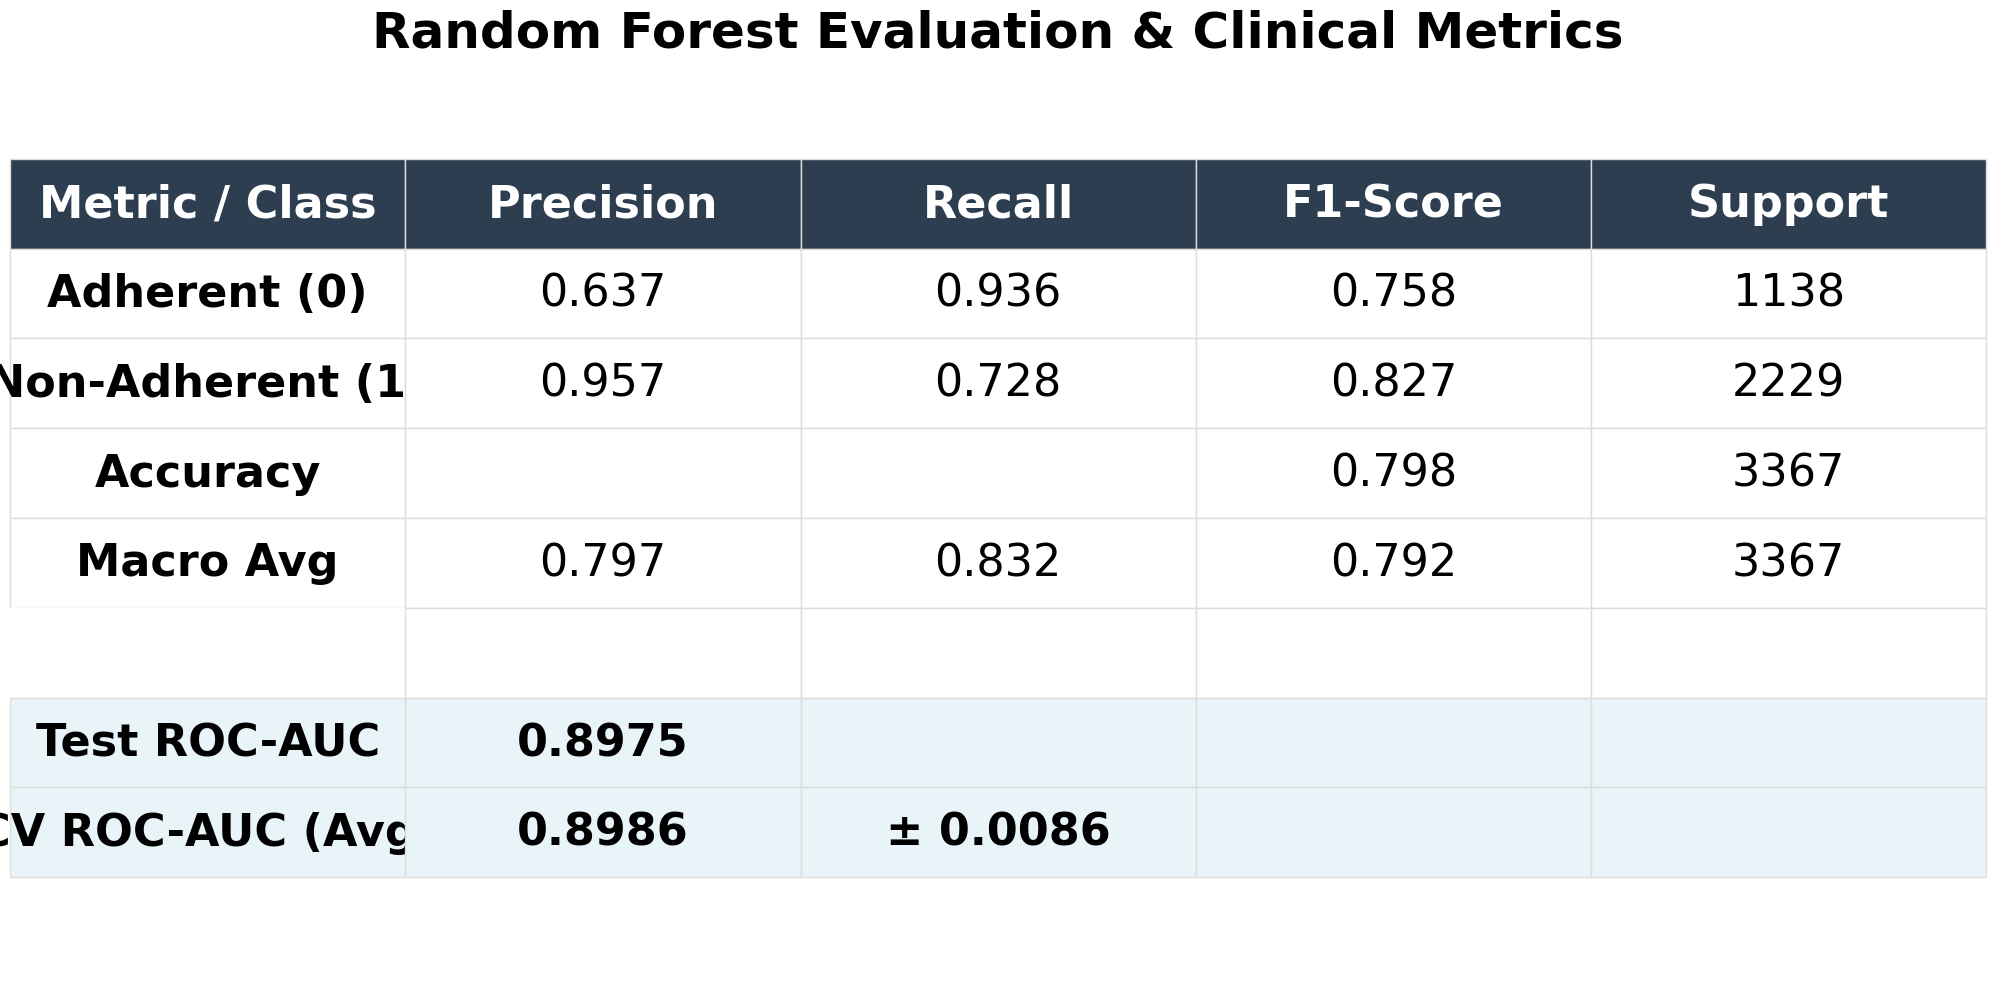

✅ Success! Random Forest table saved to /content/Output/


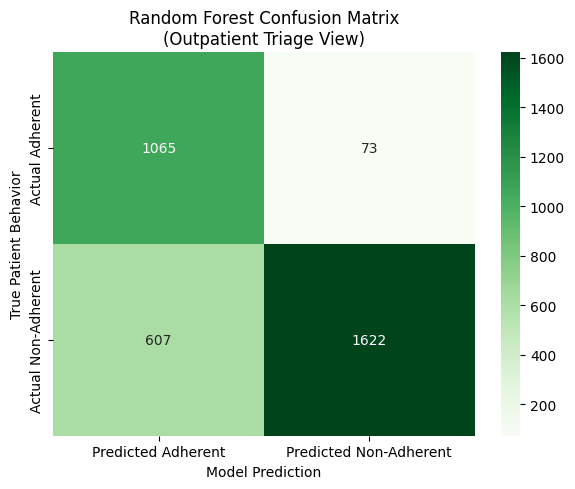

EXTRACTING FEATURE IMPORTANCE (THE 'WHY')
Top 10 Drivers of Behavior (Non-Linear Interactions):
--------------------------------------------------
                   Feature  Importance
     TOTAL_PHARMACY_VISITS    0.871527
               CURRENT AGE    0.099406
        ANNUALCONTRIBUTION    0.012492
                  GENDER_M    0.005122
DISEASE_GROUP_Hypertension    0.005089
        SCHEMETYPE_PREMIUM    0.002721
        COVERTYPE_STANDARD    0.001836
         SCHEMETYPE_MEDIUM    0.001807


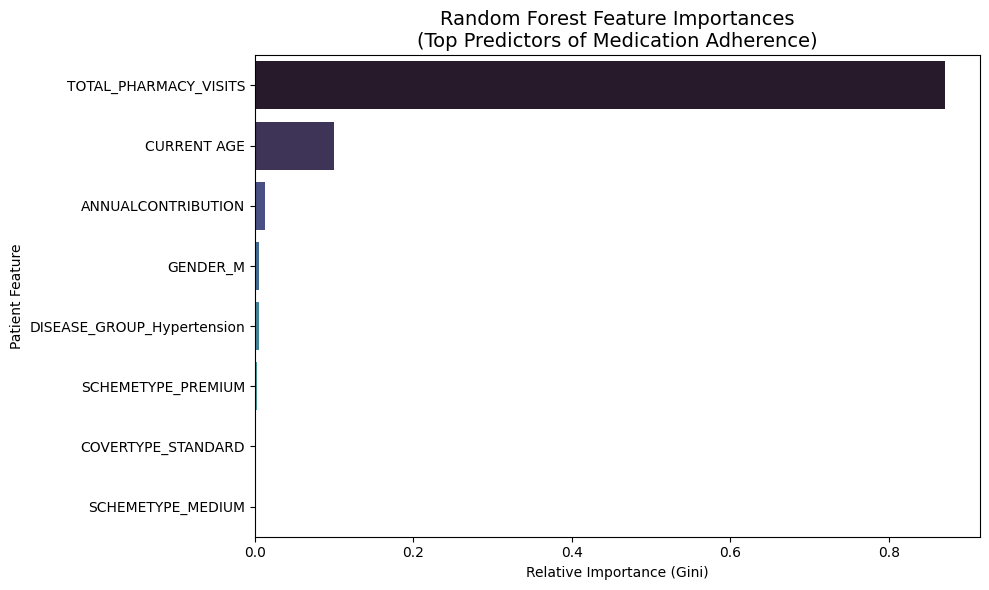


Success! Saved RF Importances and Plots.


In [ ]:
######################
# RANDOM FOREST MODEL
######################

print("TRAINING RANDOM FOREST")
rf_model = RandomForestClassifier(n_estimators=150, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# =========================================================
# 1. TRAIN THE RANDOM FOREST (THE TRIAGE ENGINE)
# =========================================================
print("TRAINING RANDOM FOREST...")
# Using standard robust parameters for clinical data
rf_model = RandomForestClassifier(n_estimators=150, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Generate Predictions
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict(X_test)

# Calculate Core Metrics
rf_auc = roc_auc_score(y_test, rf_prob)
print(f"🏆 Random Forest ROC-AUC Score: {rf_auc:.4f}")

# Cross-Validation (Robustness Check)
print("RUNNING CROSS-VALIDATION...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')

# =========================================================
# 2. GENERATING THE HIGH-RES METRICS TABLE PNG
# =========================================================
print("GENERATING HIGH-RES POSTER TABLE...")

# Extract report as dictionary to format into a table
report_dict_rf = classification_report(y_test, rf_pred, target_names=['Adherent (0)', 'Non-Adherent (1)'], output_dict=True)
report_df_rf = pd.DataFrame(report_dict_rf).transpose()

# Prepare table data
table_data_rf = []
columns = ['Metric / Class', 'Precision', 'Recall', 'F1-Score', 'Support']

# Add class rows
for row in ['Adherent (0)', 'Non-Adherent (1)']:
    table_data_rf.append([
        row,
        f"{report_df_rf.loc[row, 'precision']:.3f}",
        f"{report_df_rf.loc[row, 'recall']:.3f}",
        f"{report_df_rf.loc[row, 'f1-score']:.3f}",
        f"{int(report_df_rf.loc[row, 'support'])}"
    ])

# Add summary rows
table_data_rf.append(['Accuracy', '', '', f"{report_df_rf.loc['accuracy', 'f1-score']:.3f}", f"{int(report_df_rf.loc['macro avg', 'support'])}"])
table_data_rf.append(['Macro Avg', f"{report_df_rf.loc['macro avg', 'precision']:.3f}", f"{report_df_rf.loc['macro avg', 'recall']:.3f}", f"{report_df_rf.loc['macro avg', 'f1-score']:.3f}", f"{int(report_df_rf.loc['macro avg', 'support'])}"])

# Add space and overall AUC metrics
table_data_rf.append(['', '', '', '', ''])
table_data_rf.append(['Test ROC-AUC', f"{rf_auc:.4f}", '', '', ''])
table_data_rf.append(['CV ROC-AUC (Avg)', f"{rf_cv_scores.mean():.4f}", f"± {rf_cv_scores.std()*2:.4f}", '', ''])

# Create WIDER Figure
fig, ax = plt.subplots(figsize=(22, 10))
ax.axis('off')

# Reduce space between title and table using negative pad
plt.title('Random Forest Evaluation & Clinical Metrics', fontsize=36, fontweight='bold', pad=-10)

# Render Table
table = ax.table(cellText=table_data_rf, colLabels=columns, cellLoc='center', loc='center')

# Style Table - Bigger and Wider
table.auto_set_font_size(False)
table.set_fontsize(32)
table.scale(1.5, 4.5)

# Format Colors and Headers
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#dddddd')
    # Header styling
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    # Make metric names bold
    elif col == 0:
        cell.set_text_props(weight='bold')

    # Custom bolding for bottom AUC section
    if row > (len(table_data_rf) - 2):
        cell.set_facecolor('#e8f4f8')
        cell.set_text_props(weight='bold')
    # Make empty separator row totally blank
    elif row == len(table_data_rf) - 2 and col == 0:
         cell.set_edgecolor('none')

plt.tight_layout()
# Save to output folder
os.makedirs('/content/Output', exist_ok=True)
plt.savefig('/content/Output/Random_Forest_Evaluation_Metrics_Table_Wider.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Success! Random Forest table saved to /content/Output/")

# Visualizing the Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 5))
# Using a green color map to distinguish from the Lasso chart
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Adherent', 'Predicted Non-Adherent'],
            yticklabels=['Actual Adherent', 'Actual Non-Adherent'])
plt.title('Random Forest Confusion Matrix\n(Outpatient Triage View)')
plt.ylabel('True Patient Behavior')
plt.xlabel('Model Prediction')
plt.tight_layout()
os.makedirs('/content/Output', exist_ok=True)
plt.savefig('/content/Output/RF_Confusion_Matrix.png', dpi=300)
plt.show()

print("EXTRACTING FEATURE IMPORTANCE (THE 'WHY')")
# Random Forest uses Gini Importance instead of coefficients.
# It measures how often a feature is used to make a critical decision across all the trees.
rf_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 10 Drivers of Behavior (Non-Linear Interactions):")
print("-" * 50)
print(rf_importances.head(10).to_string(index=False))

# Save to CSV for the report
rf_importances.to_csv("/content/Output/RF_Feature_Importances.csv", index=False)

# --- VISUALIZATION: THE IMPORTANCE PLOT ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importances.head(10), hue='Feature', palette='mako', legend=False)
plt.title('Random Forest Feature Importances\n(Top Predictors of Medication Adherence)', fontsize=14)
plt.xlabel('Relative Importance (Gini)')
plt.ylabel('Patient Feature')
plt.tight_layout()
plt.savefig('/content/Output/RF_Importance_Plot.png', dpi=300)
plt.show()

print("\nSuccess! Saved RF Importances and Plots.")

In [ ]:
################
# PREPROCESSING
################

# Adherence Label
threshold = 5
df['AdherenceLabel'] = (df['MedicationAdherence'] >= threshold).astype(int)

# Exclude patient IDs and target variables
exclude_from_X = ['PatientID', 'DoctorInCharge', 'MedicationAdherence', 'AdherenceLabel']

# SMOTE for Random Forest model
smote = SMOTE(random_state=42)

# Define X and y
X = df.drop(columns=exclude_from_X, errors='ignore')
y = df['AdherenceLabel']

# 4. Split the Data (70/30 Split)
# stratify=y since your adherent group is small (~20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Preprocessing Complete.")
print(f"Features in X: {X.shape[1]}")
print(f"Target distribution in y_train:\n{y_train.value_counts(normalize=True)}")

Preprocessing Complete.
Features in X: 51
Target distribution in y_train:
AdherenceLabel
0    0.503015
1    0.496985
Name: proportion, dtype: float64


=== 1. PREPARING DATA FOR SURVIVAL ANALYSIS ===

=== 2. GENERATING SURVIVAL TABLES & CURVES ===

📊 TABLE 1: PATIENT ADHERENCE OVER TIME (KAPLAN-MEIER)
---------------------------------------------------------------------------
| Insurance Tier   | Month 1   | Month 3   | Month 6   | Month 9   | Month 12   |
|:-----------------|:----------|:----------|:----------|:----------|:-----------|
| BASIC            | 77.9%     | 60.6%     | 45.0%     | 24.7%     | 8.2%       |
| MEDIUM           | 80.8%     | 65.9%     | 49.2%     | 29.0%     | 10.1%      |
| PREMIUM          | 85.3%     | 72.8%     | 57.3%     | 35.9%     | 13.6%      |
---------------------------------------------------------------------------



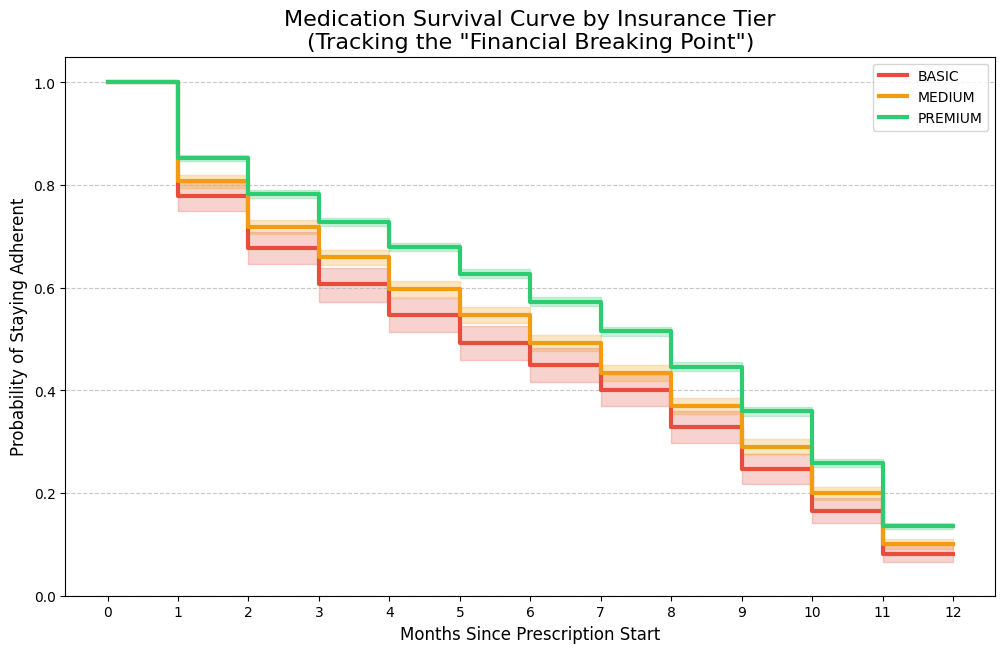


=== 3. COX PROPORTIONAL HAZARDS MODEL (THE RISK MATH) ===

📊 TABLE 2: SYSTEMIC RISK FACTORS (COX PROPORTIONAL HAZARDS)
----------------------------------------------------------------------------------------------------
| covariate             |   Hazard Ratio (Risk) |   Lower 95% CI |   Upper 95% CI |   P-Value | Clinical Translation           |
|:----------------------|----------------------:|---------------:|---------------:|----------:|:-------------------------------|
| CURRENT AGE           |                0.9914 |         0.9903 |         0.9925 |    0      | Protective (0.9% lower risk)   |
| ANNUALCONTRIBUTION    |                1      |         1      |         1      |    0.0168 | Neutral                        |
| TOTAL_PHARMACY_VISITS |                0.9451 |         0.9436 |         0.9465 |    0      | Protective (5.5% lower risk)   |
| SCHEMETYPE_MEDIUM     |                1.0046 |         0.9475 |         1.0653 |    0.8769 | Risk Factor (0.5% higher risk) |
| SCH

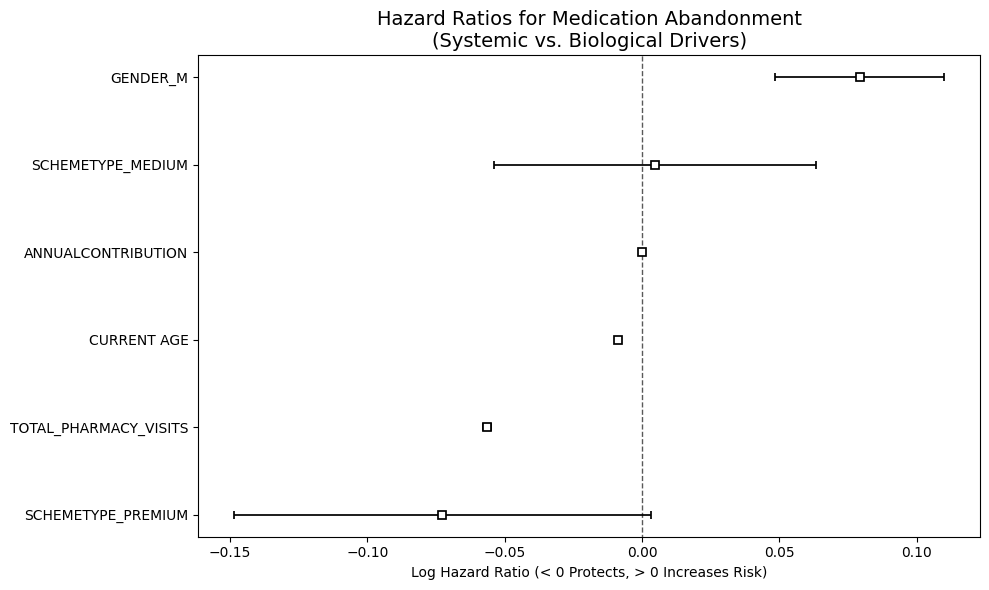


Success! Tables printed and visuals saved.


In [ ]:
####################
# SURVIVAL ANALYSIS
####################

print("=== 1. PREPARING DATA FOR SURVIVAL ANALYSIS ===\n")

# Use df_patients to access the raw ADHERENCE column to measure 'Time'
df_survival = df_patients.dropna().copy()

# Define TIME: How many months did they last? (Max is 12)
df_survival['TIME'] = df_survival['ADHERENCE']

# Define EVENT: 1 = They dropped off before 12 months, 0 = They survived the whole year
df_survival['EVENT'] = (df_survival['ADHERENCE'] < 12).astype(int)

print("=== 2. GENERATING SURVIVAL TABLES & CURVES ===\n")

plt.figure(figsize=(12, 7))
kmf = KaplanMeierFitter()
colors = {'BASIC': '#e74c3c', 'MEDIUM': '#f39c12', 'PREMIUM': '#2ecc71'}

# We will collect the survival rates at specific months to build a clean table
time_points = [1, 3, 6, 9, 12]
survival_data = []

for scheme in ['BASIC', 'MEDIUM', 'PREMIUM']:
    mask = df_survival['SCHEMETYPE'] == scheme
    kmf.fit(df_survival['TIME'][mask], event_observed=df_survival['EVENT'][mask], label=f"{scheme}")

    # Plot the curve
    kmf.plot_survival_function(ci_show=True, color=colors[scheme], linewidth=3)

    # Extract survival probabilities for our table
    surv_probs = kmf.survival_function_.reindex(time_points, method='pad')
    rates = (surv_probs[f"{scheme}"] * 100).round(1).astype(str) + '%'

    row_data = {'Insurance Tier': scheme}
    for t, rate in zip(time_points, rates):
        row_data[f'Month {t}'] = rate
    survival_data.append(row_data)

# Create and print the clean Survival Table
df_surv_table = pd.DataFrame(survival_data)
print("📊 TABLE 1: PATIENT ADHERENCE OVER TIME (KAPLAN-MEIER)")
print("-" * 75)
print(df_surv_table.to_markdown(index=False))
print("-" * 75 + "\n")

# Formatting the Chart
plt.title('Medication Survival Curve by Insurance Tier\n(Tracking the "Financial Breaking Point")', fontsize=16)
plt.xlabel('Months Since Prescription Start', fontsize=12)
plt.ylabel('Probability of Staying Adherent', fontsize=12)
plt.xticks(np.arange(0, 13, 1))
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
os.makedirs('/content/Output', exist_ok=True)
plt.savefig('/content/Output/Kaplan_Meier_Curve.png', dpi=300)
plt.show()

print("\n=== 3. COX PROPORTIONAL HAZARDS MODEL (THE RISK MATH) ===\n")

features_for_cox = ['TIME', 'EVENT', 'CURRENT AGE', 'ANNUALCONTRIBUTION',
                    'TOTAL_PHARMACY_VISITS', 'SCHEMETYPE', 'GENDER']
df_cox = df_survival[features_for_cox].copy()

# One-Hot Encode
df_cox = pd.get_dummies(df_cox, drop_first=True)

# Fit the Cox model
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox, duration_col='TIME', event_col='EVENT')

# Extract and format the summary table
summary_df = cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
summary_df.columns = ['Hazard Ratio (Risk)', 'Lower 95% CI', 'Upper 95% CI', 'P-Value']
summary_df = summary_df.round(4)

# Add a "Translation" column to make it instantly readable
def interpret_risk(hr):
    if hr < 1:
        return f"Protective ({(1-hr)*100:.1f}% lower risk)"
    elif hr > 1:
        return f"Risk Factor ({(hr-1)*100:.1f}% higher risk)"
    return "Neutral"

summary_df['Clinical Translation'] = summary_df['Hazard Ratio (Risk)'].apply(interpret_risk)

print("📊 TABLE 2: SYSTEMIC RISK FACTORS (COX PROPORTIONAL HAZARDS)")
print("-" * 100)
print(summary_df.to_markdown())
print("-" * 100)

# Visualize the Hazard Ratios
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Hazard Ratios for Medication Abandonment\n(Systemic vs. Biological Drivers)', fontsize=14)
plt.xlabel('Log Hazard Ratio (< 0 Protects, > 0 Increases Risk)')
plt.tight_layout()
plt.savefig('/content/Output/Cox_Hazard_Ratios.png', dpi=300)
plt.show()

print("\nSuccess! Tables printed and visuals saved.")